# PaNS – Cvičenie 3 (PyTorch, 100 min)
## Malá neurónová sieť, učenie, vizualizácia tréningu (MSE)

**Ciele:**
- pripomenúť si, že učenie je minimalizácia stratovej funkcie (MSE ako kvadratická funkcia)
- ukázať gradientný zostup v 1D/2D a rolu **learning rate**
- natrénovať jednoduché **MLP (fully-connected)** na MNIST v **PyTorch**
- vizualizovať priebeh: **loss** a **accuracy** cez epochy, tréning vs. validácia


> Pozn.: Pre klasifikáciu je zvyčajne vhodnejšia cross-entropy, ale dnes použijeme **MSE** ako didaktický most ku kvadratickej strate z prednášky.


In [7]:
# @title Imports + základné nastavenia (PyTorch)
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, TensorDataset

import torchvision
from torchvision import transforms

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# pri viacerych gpu moze byt cuda:0, cuda:1, ..., cuda:n
print("Device:", device)


PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Device: cpu


---
## 1) Warm-up: minimalizácia kvadratickej funkcie v 1D (gradientný zostup)

Funkcia:
\[ f(w) = (w - 3)^2 \]

Gradient:
\[ f'(w) = 2(w-3) \]

**Úloha:** pohrajte sa s `lr` (learning rate). Čo sa stane, keď je príliš malé / príliš veľké?


### Poznámky pre vyučujúceho: čo poviem
**1D kvadratická funkcia a learning rate**

- Tu si zredukujeme učenie na jednu premennú `w`. Funkcia \(f(w)=(w-3)^2\) je náš mini „loss“ – analógia ku kvadratickej chybe/MSE.
- Gradient hovorí smer najrýchlejšieho rastu; my ideme **proti gradientu**, lebo chceme klesať.
- Zdôrazním veľkosť kroku: `lr` = learning rate. Malé `lr` → pomalé. Príliš veľké → preskakovanie minima, oscilácie, divergenica.
- Graf mi ukaže klesanie stratovej funkcie
- Na tabulu nakreslím graf stratovej funkcie a nakreslím, ako sa na tom grafe zhruba hýbeme.
- Prepojím na prednášku: v sieti je to isté, len namiesto 1D máme veľa-D (milióny parametrov).


In [8]:
# @title 1D gradient descent demo
# TODO funkcie f - funkcia straty, grad_f - gradient funkcie (prva derivacia), gradient_descent_1d - vypocet gradient descent pre 1 vahu pri danom lr na urcity pocet krokov

# f(w) = (w-3)^2
def f(w):
    return (w-3) ** 2


# derivacia f
def grad_f(w): 
    return 2 * (w-3)


def gradient_descent_1d(w0=10, lr=0.1, steps=30): 
    ws = [w0]
    fs = [f(w0)]
    w = w0

    for _ in range(steps): 
        w -= lr * grad_f(w)

        ws.append(w)
        fs.append(f(w))

    return np.array(ws), np.array(fs)



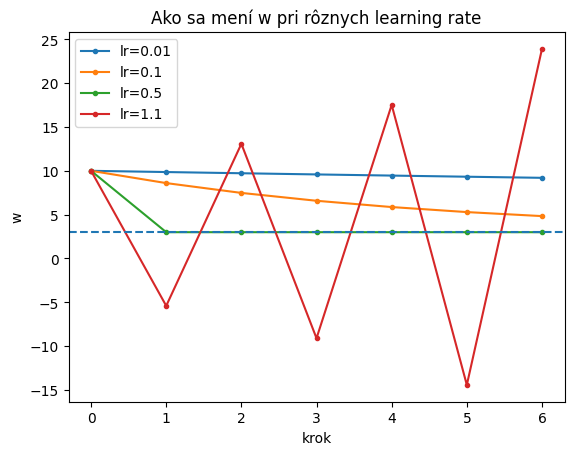

In [9]:
# TODO: skúste napr. 0.01, 0.1, 0.5, 1.1
lrs = [0.01, 0.1, 0.5, 1.1]
# lrs = [0.01]

w0 = 10.0
steps = 6

# Pohyb po parabole f(w) pre rôzne lr
plt.figure()
for lr in lrs:
    # vahy, funkcne hodnoty
    ws, fs = gradient_descent_1d(w0=w0, lr=lr, steps=steps)
    plt.plot(ws, marker="o", markersize=3, label=f"lr={lr}")
plt.axhline(3.0, linestyle="--")
plt.xlabel("krok")
plt.ylabel("w")
plt.title("Ako sa mení w pri rôznych learning rate")
plt.legend()
plt.show()


---
## 2) Warm-up: MSE pri lineárnej regresii v 2D (w, b)

Model: $\hat{y} = wx + b$

Strata (MSE):

$$
\mathrm{MSE}(w,b) = \frac{1}{N}\sum_i (wx_i + b - y_i)^2
$$


**Úloha:** pozorujte, ako sa mení konvergencia pri rôznych `lr`.


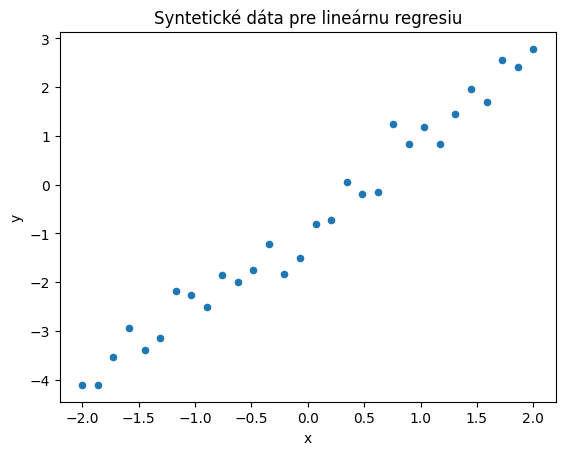

In [10]:
# @title Syntetické dáta + MSE v 2D a gradient descent (numpy)
N = 30
x = np.linspace(-2, 2, N)
true_w, true_b = 1.8, -0.7
y = true_w*x + true_b + 0.4*np.random.randn(N)

plt.figure()
plt.scatter(x, y, s=20)
plt.title("Syntetické dáta pre lineárnu regresiu")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

# TODO funkcie mse pre vypocet chyby, grad_mse, gd_2d
def mse(w, b): 
    yhat = w*x - b  # linearna regresia 
    return np.mean((yhat - y) ** 2)

def grad_mse(w, b): 
    yhat = w*x - b
    err = yhat - y

    # derivacia (gradient)
    dw = 2 * np.mean(err * x)
    db = 2 * np.mean(err)

    return dw, db

# gradient descent 
def gd_2d(w0=0, b0=0, lr=0.1, steps=30): 
    w, b = w0, b0 
    traj = [(w, b, mse(w, b))]

    for _ in range(steps): 
        dw, db = grad_mse(w, b) 
        w -= lr * dw 
        b -= lr * db
        traj.append((w, b, mse(w, b)))

    return np.array(traj)


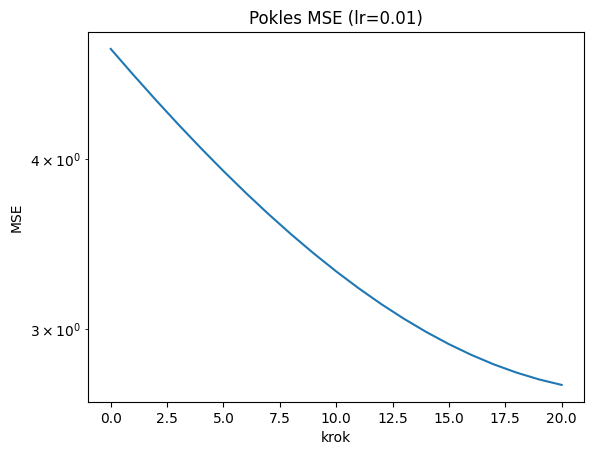

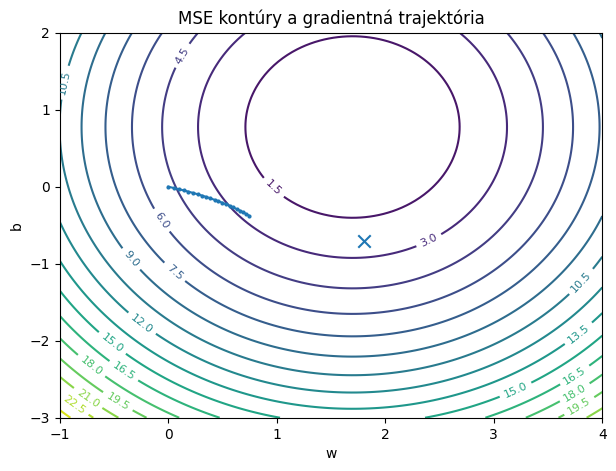

In [21]:
# TODO: skúste napr. 0.01, 0.05, 0.2
lr = 0.01
steps = 20
traj = gd_2d(w0=0.0, b0=0.0, lr=lr, steps=steps)

plt.figure()
plt.plot(traj[:,2])
plt.yscale("log")
plt.title(f"Pokles MSE (lr={lr})")
plt.xlabel("krok"); plt.ylabel("MSE")
plt.show()

W = np.linspace(-1, 4, 120)
B = np.linspace(-3, 2, 120)
WW, BB = np.meshgrid(W, B)
ZZ = np.vectorize(mse)(WW, BB)

plt.figure(figsize=(7,5))
cs = plt.contour(WW, BB, ZZ, levels=20)
plt.clabel(cs, inline=True, fontsize=8)
plt.plot(traj[:,0], traj[:,1], marker="o", markersize=2)
plt.scatter([true_w],[true_b], marker="x", s=80)
plt.title("MSE kontúry a gradientná trajektória")
plt.xlabel("w"); plt.ylabel("b")
plt.show()


---
## 3) MNIST: malá neurónka (MLP) – 2 plne prepojené vrstvy (PyTorch)

Model:
- `Flatten`
- `Linear(hidden_units) + ReLU`
- `Linear(10)` (logity)

Strata:
- **Mean Squared Error (MSE)** medzi `softmax(logits)` a **one-hot** labelom

**Úlohy:**
1. Skúste zmeniť `learning_rate` a sledujte grafy.
2. Skúste zvýšiť počet epoch – uvidíte **overfitting** (val_loss začne rásť).
3. Zapnite **EarlyStopping** a porovnajte.


In [27]:
# @title Načítanie MNIST (torchvision) + train/val split
# TODO vytvorenie transformacnej funkcie, zatial len to tensor, dá hodnoty v [0,1], tvar [1,28,28]
# tensor = viacrozmerne pole 
transform = transforms.ToTensor()

# TODO nacitanie train a test z mnistu z priecinku ./data
train_full = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# TODO vytvorenie validacnej sady z train
val_size = 10_000
train_size = len(train_full) - val_size
train_ds, val_ds = random_split(train_full, (train_size, val_size), torch.Generator().manual_seed(SEED))

print(f"Train: {train_ds}, Val: {val_ds}, Test: {test_ds}")


Train: <torch.utils.data.dataset.Subset object at 0x7f4be09428b0>, Val: <torch.utils.data.dataset.Subset object at 0x7f4be094a9f0>, Test: Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()


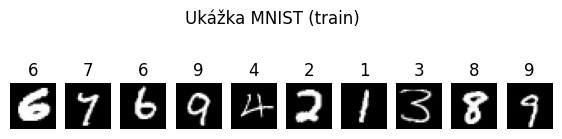

In [30]:
plt.figure(figsize=(7,2))
for i in range(10):
    x_img, y_int = train_ds[i]
    plt.subplot(1,10,i+1)
    plt.imshow(x_img.squeeze(0), cmap="gray")
    plt.axis("off")
    plt.title(str(int(y_int)))
plt.suptitle("Ukážka MNIST (train)")
plt.show()

---
### One-hot labely a MSE: mini príklad (intuícia)

Pri klasifikácii (10 tried) dáva MSE zmysel vtedy, keď **cieľ** aj **predikcia** majú rovnaký tvar: 10-prvkový vektor.

- Integer label (napr. `7`) premeníme na **one-hot** vektor dĺžky 10:  
  `7 → [0,0,0,0,0,0,0,1,0,0]`
- Sieť predikuje tiež 10 čísel (napr. softmax pravdepodobnosti).
- MSE potom počíta priemerný kvadratický rozdiel medzi týmito dvoma vektormi.


In [31]:
# @title One-hot + MSE na jednom príklade (PyTorch)
y_int = 7
y_oh = F.one_hot(torch.tensor(y_int), num_classes=10).float()

print("Integer label:", y_int)
print("One-hot label: ", y_oh.int().tolist())

y_pred = torch.tensor([0.01, 0.02, 0.01, 0.01, 0.03, 0.02, 0.05, 0.78, 0.04, 0.03])
print("\nPredikcia:", torch.round(y_pred*100)/100)
print("Predikovaná trieda:", int(torch.argmax(y_pred)))

mse = torch.mean((y_pred - y_oh)**2)
print("\nMSE(y_pred, y_onehot) =", float(mse))

y_pred_bad = torch.tensor([0.10]*10)
mse_bad = torch.mean((y_pred_bad - y_oh)**2)
print("MSE pri 'plochom' odhade =", float(mse_bad))


Integer label: 7
One-hot label:  [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

Predikcia: tensor([0.0100, 0.0200, 0.0100, 0.0100, 0.0300, 0.0200, 0.0500, 0.7800, 0.0400,
        0.0300])
Predikovaná trieda: 7

MSE(y_pred, y_onehot) = 0.005540001206099987
MSE pri 'plochom' odhade = 0.08999999612569809


### Poznámky pre vyučujúceho: čo poviem
**MLP architektúra, hyperparametre a význam straty (PyTorch)**

- Toto je najjednoduchšia „malá neurónka“: `Flatten → Linear(ReLU) → Linear`.
- Nakreslím schému na tabuľu.
- Spýtam sa, koľko parametrov má prvá vrstva (784x32 + 32), koľko druhá vrstva (32 x 10 + 10), ukáže sa to vo výpise.- Dnes zámerne minimalizujeme **MSE** aj pri klasifikácii – ako didaktický most ku kvadratickej funkcii z prednášky.
- Doplním, že v praxi sa na klasifikáciu bežne používa cross-entropy, lebo má lepšie vlastnosti pre pravdepodobnosti a gradienty.
- Technické záležitosti: `learning_rate`, `epochs`, `batch_size`, inicializácia (PyTorch defaulty sú rozumné).
- Zmenou `hidden_units` meníme kapacitu modelu: väčší model sa vie naučiť viac, ale ľahšie sa preučí.
- `EarlyStopping`: „stopni, keď sa val_loss prestáva zlepšovať“ – praktický nástroj proti overfittingu.



In [ ]:
# @title Model (2 FC vrstvy)
class MLP(nn.Module):
    def __init__(self, hidden_units=128):
        super().__init__()
        # TODO definovanie jednoduchej 2-vrstvovej siete
    def forward(self, x):
        return self.net(x)


In [ ]:
# @title Prvy model a pocet parametrov
hidden_units = 32     # TODO: skúste 32, 64, 256
model = MLP(hidden_units=hidden_units).to(device)

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

print(model)  # shows the layers / structure
total, trainable = count_params(model)
print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

In [ ]:

learning_rate = 1e-3   # TODO: skúste 1e-4, 1e-2
batch_size = 64       # TODO: skúste 32, 256
epochs = 16            # TODO: skúste 5, 20, 50


opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
mse_loss = nn.MSELoss()

# Early stopping (zatial vypnuté) – nastavte use_early_stopping=True
use_early_stopping = False  # TODO: prepni na True
patience = 3
best_val = float("inf")
pat_count = 0
best_state = None

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

In [ ]:
# @title Nacitanie datasetov

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
# @title Model + tréning (PyTorch, MSE)

def run_epoch(loader, training: bool):
    if training:
        # TODO nastavit model do trenovacieho modu
        model.train()
    else:
        # TODO nastavit model do validacneho modu
        model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y_int in loader:
        # TODO poslat data na device a vypocitat one-hot vektor

        # TODO vycistit gradienty pre trening

        # TODO urobit forward pass a vypocitat loss

        # TODO pre trening urobit aj backward pass

        total_loss += loss.item() * x.size(0)
        pred = torch.argmax(probs, dim=1)
        correct += (pred == y_int).sum().item()
        total += x.size(0)

    return total_loss/total, correct/total

for epoch in range(1, epochs+1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    va_loss, va_acc = run_epoch(val_loader, training=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")

    if use_early_stopping:
        if va_loss < best_val - 1e-6:
            best_val = va_loss
            pat_count = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            pat_count += 1
            if pat_count >= patience:
                print(f"Early stopping: val_loss sa nezlepšil {patience} epochy.")
                break

if use_early_stopping and best_state is not None:
    model.load_state_dict(best_state)

In [ ]:
# @title Vizualizácia tréningu (loss a accuracy)
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss (MSE)")
plt.title("Pokles stratovej funkcie (MSE)")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy cez epochy")
plt.legend()
plt.show()


In [ ]:
# @title Vyhodnotenie na teste + pár predikcií
model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for x, y_int in test_loader:
        x = x.to(device, non_blocking=True)
        y_int = y_int.to(device, non_blocking=True)
        y_oh = F.one_hot(y_int, num_classes=10).float()

        logits = model(x)
        probs = F.softmax(logits, dim=1)
        loss = mse_loss(probs, y_oh)

        test_loss += loss.item() * x.size(0)
        pred = torch.argmax(probs, dim=1)
        correct += (pred == y_int).sum().item()
        total += x.size(0)

test_loss /= total
test_acc = correct / total
print(f"Test loss (MSE): {test_loss:.4f} | Test acc: {test_acc:.4f}")

idx = np.random.choice(len(test_ds), size=12, replace=False)
plt.figure(figsize=(10,3))

for i, k in enumerate(idx):
    x_img, y_true = test_ds[int(k)]
    x_in = x_img.unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(x_in), dim=1).cpu().numpy()[0]
    y_pred = int(np.argmax(probs))

    plt.subplot(2,6,i+1)
    plt.imshow(x_img.squeeze(0), cmap="gray")
    plt.axis("off")
    plt.title(f"y={int(y_true)}, ŷ={y_pred}", fontsize=10)

plt.suptitle("Ukážkové predikcie", fontsize=14, y=1.05)  # posuň suptitle vyššie
plt.tight_layout()  # automaticky upraví medzery medzi subplots
plt.show()


---
## 4) Krátka vložka: čo je „backprop“ v praxi (PyTorch autograd)

PyTorch si pamätá výpočet (computational graph) a cez `loss.backward()` dopočíta gradienty (reťazové pravidlo).


In [ ]:
# @title Autograd demo (1 batch)
model.train()
x, y_int = next(iter(train_loader))
x = x.to(device)
y_int = y_int.to(device)
y_oh = F.one_hot(y_int, num_classes=10).float()

opt.zero_grad(set_to_none=True)

logits = model(x)
probs = F.softmax(logits, dim=1)
loss = mse_loss(probs, y_oh)
loss.backward()

print("Loss na batchi:", float(loss))
for name, p in model.named_parameters():
    if "weight" in name:
        print("Prvý parameter:", name, "tvar", tuple(p.shape))
        print("Norma jeho gradientu:", float(p.grad.norm()))
        break
